In [1]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Dataset path
base_path = r"C:\Users\deepi\Downloads\archive\PetImages"

data = []
labels = []

img_size = 64
categories = ['Cat', 'Dog']

for category in categories:
    path = os.path.join(base_path, category)
    label = categories.index(category)

    count = 0
    for img in os.listdir(path):
        if count >= 500:   # limit for small dataset
            break
        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.resize(image, (img_size, img_size))
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # HOG features
            features = hog(gray,
                           orientations=9,
                           pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2),
                           block_norm='L2-Hys')

            data.append(features)
            labels.append(label)

            count += 1

        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

# Train SVM
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Data shape: (1000, 1764)
Accuracy: 0.71


In [6]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (64, 64))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys')

    features = features.reshape(1, -1)

    prediction = model.predict(features)

    if prediction == 0:
        print("Cat")
    else:
        print("Dog")

# Test
predict_image(r"C:\Users\deepi\Downloads\test.jpg")

Cat


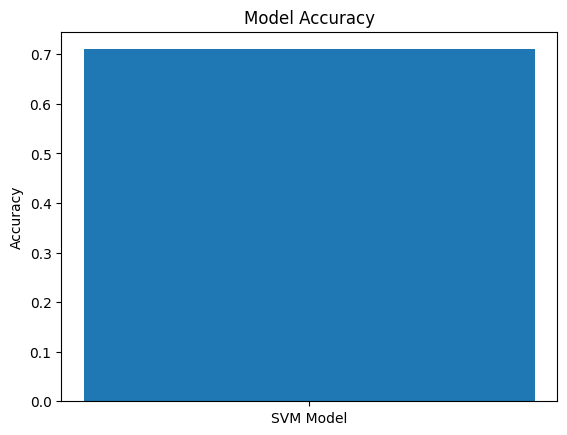

In [8]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

plt.bar(['SVM Model'], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

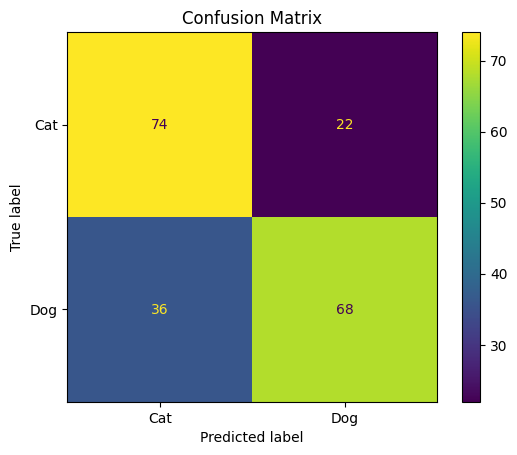

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()